In [1]:
import polars as pl

pdb_af3 = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet"
).filter(pl.col("pdb") != "8trr")

In [2]:
import MDAnalysis as mda
from pathlib import Path
import numpy as np
from mdaf3.AF3OutputParser import AF3Output
from mdaf3.FeatureExtraction import serial_apply
import math

cleaned_pdb = Path("../../data/pdb/triad/cleaned_pdb")
inf_dir = Path("../../data/pdb/triad/inference")


def align_mhc_to_origin(u, mhc_axes, mhc_origin):

    u_rot = np.linalg.solve(mhc_axes.T, np.eye(3, 3)).T

    # translate and rotate positions in a way that puts
    # mhc coordinate frame at the origin and aligns it
    # to the coordinate axes

    u.atoms.positions = (u.atoms.positions + (mhc_origin * -1)) @ u_rot

    return u


def check_reversals(row, clean_pdb_dir, inf_dir, rank):
    """
    Implementation of CDR center-of-mass RMSD after MHC alignment
    """

    sample_id = row[f"pred_sample_rank_{rank}"]

    inf_cls = AF3Output
    sample_kwarg = {"seed": sample_id}

    pred_u = inf_cls(inf_dir / row["job_name"]).get_mda_universe(**sample_kwarg)
    pred_mhc_axes = np.array(row[f"pred_mhc_axes_{rank}"])
    pred_mhc_origin = np.array(row[f"pred_mhc_origin_{rank}"])

    pred_u = align_mhc_to_origin(pred_u, pred_mhc_axes, pred_mhc_origin)

    true_u = mda.Universe(clean_pdb_dir / f"{row['pdb']}.pdb")
    true_mhc_axes = np.array(row[f"true_mhc_axes"])
    true_mhc_origin = np.array(row[f"true_mhc_origin"])

    true_u = align_mhc_to_origin(true_u, true_mhc_axes, true_mhc_origin)

    pred_pep = pred_u.select_atoms("segid A").residues
    pred_pep_start = pred_pep[0].atoms.select_atoms("name CA").positions[0]
    pred_pep_end = pred_pep[-1].atoms.select_atoms("name CA").positions[0]
    pred_pep_dir = pred_pep_end - pred_pep_start
    # pred_pep_dir /= np.linalg.norm(pred_pep_dir)

    true_pep = true_u.select_atoms("segid A").residues
    true_pep_start = true_pep[0].atoms.select_atoms("name CA").positions[0]
    true_pep_end = true_pep[-1].atoms.select_atoms("name CA").positions[0]
    true_pep_dir = true_pep_end - true_pep_start
    # true_pep_dir /= np.linalg.norm(true_pep_dir)

    agreement = np.dot(pred_pep_dir, true_pep_dir)

    if agreement < 0:
        row["is_peptide_reversed"] = True
    else:
        row["is_peptide_reversed"] = False

    # check for tcr reversal
    row["true_tcr_is_reversed"] = (
        (row["true_dgeom"]["torsion"] + (math.pi / 4)) % (2 * math.pi)
    ) < math.pi
    row["pred_tcr_is_reversed"] = (
        (row["pred_dgeom_4"]["torsion"] + (math.pi / 4)) % (2 * math.pi)
    ) < math.pi

    return row


pdb_af3 = serial_apply(pdb_af3, check_reversals, cleaned_pdb, inf_dir, 4)

/tgen_labs/altin/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing rows:   0%|          | 0/151 [00:00<?, ?it/s]/tgen_labs/altin/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/MDAnalysis/coordinates/MMCIF.py:139: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


/tgen_labs/altin/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:465: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"
Processing rows: 100%|██████████| 151/151 [00:28<00:00,  5.30it/s]


In [3]:
pdb_af3.filter(pl.col("pred_tcr_is_reversed"))

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pdb,pdb_date,replication,peptide_segid,mhc_1_segid,mhc_2_segid,tcr_1_segid,tcr_2_segid,cdr_rmsd,cdr_rmsd_af2_full,cdr_rmsd_af2_trim,…,pred_tcr_origin_3,pred_dgeom_3,pred_sample_rank_3,pred_mhc_axes_4,pred_mhc_origin_4,pred_tcr_axes_4,pred_tcr_origin_4,pred_dgeom_4,pred_sample_rank_4,docking_rmsd_af3_0,cdr_rmsd_af3_0,peptide_rmsd_af3_0,mhc_rmsd_af3_0,tcr_rmsd_af3_0,docking_rmsd_af3_1,cdr_rmsd_af3_1,peptide_rmsd_af3_1,mhc_rmsd_af3_1,tcr_rmsd_af3_1,docking_rmsd_af3_2,cdr_rmsd_af3_2,peptide_rmsd_af3_2,mhc_rmsd_af3_2,tcr_rmsd_af3_2,docking_rmsd_af3_3,cdr_rmsd_af3_3,peptide_rmsd_af3_3,mhc_rmsd_af3_3,tcr_rmsd_af3_3,docking_rmsd_af3_4,cdr_rmsd_af3_4,peptide_rmsd_af3_4,mhc_rmsd_af3_4,tcr_rmsd_af3_4,is_peptide_reversed,true_tcr_is_reversed,pred_tcr_is_reversed
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,"datetime[μs, UTC]",bool,str,str,str,str,str,f64,f64,f64,…,list[f64],struct[8],i64,list[list[f64]],list[f64],list[list[f64]],list[f64],struct[8],i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool
"""c7d998b59a8543d7d9dd1fa06c1782…",true,"""RFPLTFGWCF""","""I""","""heavy""","""human""","""A*24:02""","""MGSHSMRYFSTSVSRPGRGEPRFIAVGYVD…","""light""","""human""","""B2M""","""MIQRTPKIQVYSRHPAENGKSNFLNCYVSG…","""alpha""","""human""","""MAQSVTQPDIHITVSEGASLELRCNYSYGA…","""beta""","""human""","""MDTEVTQTPKHLVMGMTNKKSLKCEQHMGH…","""YGATPY""","""YFSGDTLV""","""KRSQSS""","""CAVGAPSGAGSYQLTF""","""MGHRA""","""YSYEKL""","""PNSSL""","""CASSPTSGIYEQYF""","""3vxm""",2013-10-23 00:00:00 UTC,true,"""C""","""A""","""B""","""D""","""E""",5.19,20.74,28.74,…,"[6.365576, 2.545884, -6.607731]","{29.948759,false,0.095069,0.024303,false,-0.181692,-0.041507,0.722335}",1,"[[0.804861, -0.049483, -0.591397], [-0.267839, -0.919545, -0.287576], [-0.529586, 0.389858, -0.753359]]","[-19.432417, -0.517167, 8.29225]","[[-0.819063, -0.176595, 0.545847], [-0.376233, 0.883622, -0.278677], [-0.43311, -0.433619, -0.790184]]","[6.365576, 2.545884, -6.607731]","{29.948759,false,0.095069,0.024303,false,-0.181692,-0.041507,0.722335}",1,23.671944,21.100536,2.043558,0.754203,1.28343,23.671944,21.100536,2.043558,0.754203,1.28343,23.671944,21.100536,2.043558,0.754203,1.28343,23.671944,21.100536,2.043558,0.754203,1.28343,23.671944,21.100536,2.043558,0.754203,1.28343,false,false,true


In [4]:
pdb_af3.filter(pl.col("pdb") == "4z7v")

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pdb,pdb_date,replication,peptide_segid,mhc_1_segid,mhc_2_segid,tcr_1_segid,tcr_2_segid,cdr_rmsd,cdr_rmsd_af2_full,cdr_rmsd_af2_trim,…,pred_tcr_origin_3,pred_dgeom_3,pred_sample_rank_3,pred_mhc_axes_4,pred_mhc_origin_4,pred_tcr_axes_4,pred_tcr_origin_4,pred_dgeom_4,pred_sample_rank_4,docking_rmsd_af3_0,cdr_rmsd_af3_0,peptide_rmsd_af3_0,mhc_rmsd_af3_0,tcr_rmsd_af3_0,docking_rmsd_af3_1,cdr_rmsd_af3_1,peptide_rmsd_af3_1,mhc_rmsd_af3_1,tcr_rmsd_af3_1,docking_rmsd_af3_2,cdr_rmsd_af3_2,peptide_rmsd_af3_2,mhc_rmsd_af3_2,tcr_rmsd_af3_2,docking_rmsd_af3_3,cdr_rmsd_af3_3,peptide_rmsd_af3_3,mhc_rmsd_af3_3,tcr_rmsd_af3_3,docking_rmsd_af3_4,cdr_rmsd_af3_4,peptide_rmsd_af3_4,mhc_rmsd_af3_4,tcr_rmsd_af3_4,is_peptide_reversed,true_tcr_is_reversed,pred_tcr_is_reversed
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,"datetime[μs, UTC]",bool,str,str,str,str,str,f64,f64,f64,…,list[f64],struct[8],i64,list[list[f64]],list[f64],list[list[f64]],list[f64],struct[8],i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool
"""2eea29073169046664ee5b26b8d791…",true,"""APSGEGSFQPSQENPQGS""","""II""","""alpha""","""human""","""DQA1*03:01""","""EDIVADHVASYGVNLYQSYGPSGQYSHEFD…","""beta""","""human""","""DQB1*03:02""","""GGSIEGRGGSGASRDSPEDFVYQFKGMCYF…","""alpha""","""human""","""DAKTTQPNSMESNEEEPVHLPCNHSTISGT…","""beta""","""human""","""DSGVTQTPKHLITATGQRVTLRCSPRSGDL…","""TISGTDY""","""GLTSN""","""AEDRKS""","""CILRDSRAQKLVF""","""SGDLS""","""YYNGEE""","""FPDLH""","""CASSAGTSGEYEQYF""","""4z7v""",2015-06-03 00:00:00 UTC,true,"""I""","""C""","""D""","""E""","""F""",2.35,2.0,4.12,…,"[-11.139461, 1.467731, -7.713462]","{28.798565,false,0.09847,0.041074,false,-0.073434,0.004331,3.377378}",3,"[[-0.721533, 0.1878, -0.666424], [0.674104, -0.029143, -0.738061], [-0.158029, -0.981775, -0.105569]]","[11.028666, -3.865167, 9.878917]","[[0.759404, -0.287922, 0.583444], [0.371921, 0.927895, -0.026184], [-0.533836, 0.23688, 0.811731]]","[-11.139461, 1.467731, -7.713462]","{28.798565,false,0.09847,0.041074,false,-0.073434,0.004331,3.377378}",3,0.381584,0.652394,0.629516,0.77801,1.155817,0.38801,0.653588,0.497829,0.761813,0.772102,0.439816,0.663885,0.488493,0.820653,0.79456,0.439816,0.663885,0.488493,0.820653,0.79456,0.439816,0.663885,0.488493,0.820653,0.79456,false,false,false


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import mannwhitneyu


def plot_rmsd_bars_all(
    pdb_df: pl.DataFrame,
    inf_type: str,
    title: str | None = None,
) -> plt.Figure:
    n = pdb_df.height

    replic_means = (
        pdb_df.filter(pl.col("replication"))
        .select(
            pl.col(f"peptide_rmsd_{inf_type}_4"),
            pl.col(f"mhc_rmsd_{inf_type}_4"),
            pl.col(f"tcr_rmsd_{inf_type}_4"),
            # pl.col(f"cdr_rmsd_{inf_type}_4"),
        )
        .to_numpy()
    )
    post_means = (
        pdb_df.filter(~pl.col("replication"))
        .select(
            pl.col(f"peptide_rmsd_{inf_type}_4"),
            pl.col(f"mhc_rmsd_{inf_type}_4"),
            pl.col(f"tcr_rmsd_{inf_type}_4"),
            # pl.col(f"cdr_rmsd_{inf_type}_4"),
        )
        .to_numpy()
    )

    labels = ["Peptide RMSD", "MHC RMSD", "TCR RMSD"]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    # pre-training boxplots (blue)
    ax.boxplot(
        replic_means,
        positions=x - width / 2,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )

    # post-training boxplots (orange)
    ax.boxplot(
        post_means,
        positions=x + width / 2,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    # ax.set_yticks(np.arange(0, 21, 1))

    # y-axis label
    ax.set_ylabel(f"RMSD between true and crystal structure (Å)")

    if title:
        ax.set_title(title)

    pre_patch = Patch(
        facecolor="tab:blue",
        edgecolor="black",
        label=f"Pre-training (n={replic_means.shape[0]})",
    )
    post_patch = Patch(
        facecolor="tab:orange",
        edgecolor="black",
        label=f"Post-training (n={post_means.shape[0]})",
    )
    ax.legend(handles=[pre_patch, post_patch], loc="upper left")

    plt.tight_layout()
    return fig


def plot_rmsd_bars(
    pdb_df: pl.DataFrame,
    inf_type: str,
    rmsd_type: str,
    title: str | None = None,
) -> plt.Figure:
    """
    Plot a single RMSD type (peptide/mhc/tcr/cdr) for pre- vs post-training as side-by-side boxplots.

    Parameters
    ----------
    pdb_df : pl.DataFrame
        Must include a boolean 'replication' column and RMSD columns like:
        '<rmsd_type>_rmsd_<inf_type>_4', e.g., 'peptide_rmsd_af3_4'
    inf_type : str
        Inference type token in the column names (e.g., 'af3', 'pred', etc.)
    rmsd_type : {'peptide','mhc','tcr','cdr'}
        Which RMSD family to plot.
    title : str | None
        Optional figure title.
    """
    rmsd_type_norm = rmsd_type.lower()
    valid = {
        "peptide": "Peptide RMSD",
        "mhc": "MHC RMSD",
        "tcr": "TCR RMSD",
        "cdr": "CDR RMSD",
    }
    if rmsd_type_norm not in valid:
        raise ValueError(f"rmsd_type must be one of {list(valid)}")

    col = f"{rmsd_type_norm}_rmsd_{inf_type}_4"
    if col not in pdb_df.columns:
        raise KeyError(f"Expected column '{col}' not found in DataFrame.")

    # Split pre/post
    pre_vals = (
        pdb_df.filter(pl.col("replication")).select(pl.col(col)).to_numpy().squeeze()
    )
    post_vals = (
        pdb_df.filter(~pl.col("replication")).select(pl.col(col)).to_numpy().squeeze()
    )

    # Ensure 1D arrays
    pre_vals = np.atleast_1d(pre_vals)
    post_vals = np.atleast_1d(post_vals)

    fig, ax = plt.subplots(figsize=(5, 8))
    width = 0.35

    # Single position (x=0), two boxes offset left/right
    ax.boxplot(
        [pre_vals],
        positions=[-width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )
    ax.boxplot(
        [post_vals],
        positions=[+width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    # X tick centered at 0 with chosen label
    ax.set_xticks([0])
    ax.set_xticklabels([valid[rmsd_type_norm]], rotation=0, ha="center")

    # ax.set_ylabel("RMSD between true and crystal structure (Å)")
    if title:
        ax.set_title(title)

    pre_patch = Patch(
        facecolor="tab:blue",
        edgecolor="black",
        label=f"Pre-training (n={pre_vals.shape[0]})",
    )
    post_patch = Patch(
        facecolor="tab:orange",
        edgecolor="black",
        label=f"Post-training (n={post_vals.shape[0]})",
    )
    # ax.legend(handles=[pre_patch, post_patch], loc="upper left")

    plt.tight_layout()
    return fig


def plot_rmsd_bars_by_mhc_class(
    pdb_df: pl.DataFrame,
    inf_type: str,
    title: str | None = None,
    class_col: str = "mhc_class",
    class_order: tuple[str, str] = ("I", "II"),
) -> plt.Figure:
    """
    Makes two vertically stacked boxplot panels: one per MHC class.
    Both panels share x/y axes, and there is a single, shared legend and title.
    Expects:
      - a boolean column 'replication' (True = pre/replicate; False = post)
      - a categorical column class_col with values like "I" / "II"
      - RMSD columns: peptide_rmsd_{inf_type}_4, mhc_rmsd_{inf_type}_4, tcr_rmsd_{inf_type}_4
    """
    labels = ["Peptide RMSD", "MHC RMSD", "TCR RMSD"]
    x = np.arange(len(labels))
    width = 0.35

    # Determine which classes are present (keep requested order, drop missing)
    present = [
        c for c in class_order if c in pdb_df.get_column(class_col).unique().to_list()
    ]
    if not present:
        raise ValueError(
            f"No MHC classes from {class_order} found in column '{class_col}'."
        )

    # Build figure with one row per present class
    fig, axes = plt.subplots(
        nrows=len(present),
        ncols=1,
        figsize=(7, 5 if len(present) == 1 else 9),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )
    if len(present) == 1:
        axes = [axes]

    # Colors and legend handles (shared)
    pre_color = "tab:blue"
    post_color = "tab:orange"
    pre_patch = Patch(facecolor=pre_color, edgecolor="black", label="Pre-training")
    post_patch = Patch(facecolor=post_color, edgecolor="black", label="Post-training")

    # Helper to extract arrays per class
    def arrays_for(df: pl.DataFrame):
        replic = (
            df.filter(pl.col("replication"))
            .select(
                pl.col(f"peptide_rmsd_{inf_type}_4"),
                pl.col(f"mhc_rmsd_{inf_type}_4"),
                pl.col(f"tcr_rmsd_{inf_type}_4"),
            )
            .to_numpy()
        )
        post = (
            df.filter(~pl.col("replication"))
            .select(
                pl.col(f"peptide_rmsd_{inf_type}_4"),
                pl.col(f"mhc_rmsd_{inf_type}_4"),
                pl.col(f"tcr_rmsd_{inf_type}_4"),
            )
            .to_numpy()
        )
        return replic, post

    def run_mwu(name, a, b):
        if len(a) and len(b):
            U, p = mannwhitneyu(a, b, alternative="less", method="auto")
            print(
                f"[MHC {cls}] {name} MWU (pre < post): U={U:.3f}, p={p:.3g}, n_pre={len(a)}, n_post={len(b)}"
            )
            return U, p

    # Plot each class panel
    for ax, cls in zip(axes, present):
        sub = pdb_df.filter(pl.col(class_col) == cls)
        replic_means, post_means = arrays_for(sub)

        # Pre (left)
        ax.boxplot(
            replic_means,
            positions=x - width / 2,
            widths=width,
            patch_artist=True,
            boxprops=dict(facecolor=pre_color, edgecolor="black"),
            whiskerprops=dict(color=pre_color),
            capprops=dict(color=pre_color),
            medianprops=dict(color="black"),
            flierprops=dict(markeredgecolor=pre_color),
            showfliers=False,
            zorder=0,
        )
        for i, d in enumerate(replic_means):
            ax.scatter(
                np.random.normal(x - width / 2, 0.04, len(d)),
                d,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )
        # Post (right)
        ax.boxplot(
            post_means,
            positions=x + width / 2,
            widths=width,
            patch_artist=True,
            boxprops=dict(facecolor=post_color, edgecolor="black"),
            whiskerprops=dict(color=post_color),
            capprops=dict(color=post_color),
            medianprops=dict(color="black"),
            flierprops=dict(markeredgecolor=post_color),
            showfliers=False,
            zorder=0,
        )
        for i, d in enumerate(post_means):
            ax.scatter(
                np.random.normal(x + width / 2, 0.04, len(d)),
                d,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )

        print(post_means.shape)
        for i in range(post_means.shape[1]):

            U, p = run_mwu("AF2", replic_means[:, i], post_means[:, i])
            p = f"p={p:.2e}" if p <= 0.05 else f"p={p:.2f}"
            if ax is axes[0]:
                if i != 0:
                    y = 5
                else:
                    y = 7
                ax.text(
                    ax.get_xticks()[i],
                    y,
                    f"{p}",
                    fontsize=14,
                    bbox=dict(alpha=0.5, boxstyle="round"),
                )
            else:
                if i == 0:
                    y = 5
                else:
                    y = 7
                ax.text(
                    ax.get_xticks()[i] - width / 2,
                    y,
                    f"{p}",
                    fontsize=14,
                    bbox=dict(alpha=0.5, boxstyle="round"),
                )
            # U, p = run_mwu("AF2", replic_means, post_means)
            # ax.text(
            #     ax.get_xticks()[2],
            #     6,
            #     f"p={p:.2f}",
            #     fontsize=10,
            #     bbox=dict(alpha=0.5, boxstyle="round"),
            # )

        # ax.scatter(
        #     np.random.normal(x + width / 2, 0.04, len(post_means)),
        #     post_means,
        #     alpha=1,
        #     s=10,
        #     c="white",
        #     edgecolors="black",
        #     zorder=1,
        # )

        # Panel label (left y-axis area)
        # ax.text(
        #     0.92,
        #     0.9,
        #     f"MHC Class {cls}",
        #     transform=ax.transAxes,
        #     ha="left",
        #     va="top",
        #     fontsize=11,
        #     fontweight="bold",
        # )
        ax.set_ylabel(f"MHC Class {cls}", fontsize=18)

        # X category ticks (only on bottom panel to reduce clutter)
        if ax is axes[-1]:
            ax.set_xticks(x)
            ax.set_xticklabels(labels, fontsize=14)
        else:
            ax.set_xticks(x)
            ax.set_xticklabels([])
            ax.legend(handles=[pre_patch, post_patch], loc="upper right", fontsize=14)

    # Shared labels / title / legend
    fig.supylabel(
        "RMSD between predicted and crystal structure (Å)", x=0.07, fontsize=18
    )
    if title:
        fig.suptitle(title, y=0.95, fontsize=16, x=0.55)
    # fig.legend(
    #     handles=[pre_patch, post_patch], loc="upper right", bbox_to_anchor=(0.95, 0.95)
    # )

    # Layout: leave headroom for suptitle and legend
    fig.tight_layout(rect=[0.06, 0.05, 0.98, 0.95])
    return fig


def plot_rmsd_bars_by_mhc_class(
    pdb_df: pl.DataFrame,
    inf_type: str,
    title: str | None = None,
    class_col: str = "mhc_class",
    class_order: tuple[str, str] = ("I", "II"),
) -> plt.Figure:
    """
    Makes two vertically stacked boxplot panels: one per MHC class.
    Both panels share x/y axes, and there is a single, shared legend and title.
    Expects:
      - a boolean column 'replication' (True = pre/replicate; False = post)
      - a categorical column class_col with values like "I" / "II"
      - RMSD columns: peptide_rmsd_{inf_type}_4, mhc_rmsd_{inf_type}_4, tcr_rmsd_{inf_type}_4
    """
    labels = ["Peptide RMSD", "MHC RMSD", "TCR RMSD"]
    x = np.arange(len(labels))
    width = 0.35

    # Determine which classes are present (keep requested order, drop missing)
    present = [
        c for c in class_order if c in pdb_df.get_column(class_col).unique().to_list()
    ]
    if not present:
        raise ValueError(
            f"No MHC classes from {class_order} found in column '{class_col}'."
        )

    # Build figure with one row per present class
    fig, axes = plt.subplots(
        nrows=len(present),
        ncols=1,
        figsize=(7, 5 if len(present) == 1 else 9),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )
    if len(present) == 1:
        axes = [axes]

    # Colors and legend handles (shared)
    pre_color = "tab:blue"
    post_color = "tab:orange"
    # pre_patch = Patch(facecolor=pre_color, edgecolor="black", label="Pre-training")
    # post_patch = Patch(facecolor=post_color, edgecolor="black", label="Post-training")

    # Helper to extract arrays per class
    def arrays_for(df: pl.DataFrame):
        replic = (
            df.filter(pl.col("replication"))
            .select(
                pl.col(f"peptide_rmsd_{inf_type}_4"),
                pl.col(f"mhc_rmsd_{inf_type}_4"),
                pl.col(f"tcr_rmsd_{inf_type}_4"),
            )
            .to_numpy()
        )
        post = (
            df.filter(~pl.col("replication"))
            .select(
                pl.col(f"peptide_rmsd_{inf_type}_4"),
                pl.col(f"mhc_rmsd_{inf_type}_4"),
                pl.col(f"tcr_rmsd_{inf_type}_4"),
            )
            .to_numpy()
        )
        return replic, post

    def run_mwu(name, a, b):
        if len(a) and len(b):
            U, p = mannwhitneyu(a, b, alternative="less", method="auto")
            print(
                f"[MHC {cls}] {name} MWU (pre < post): U={U:.3f}, p={p:.3g}, n_pre={len(a)}, n_post={len(b)}"
            )
            return U, p

    pre_p = []
    post_p = []

    # Plot each class panel
    for ax, cls in zip(axes, present):
        sub = pdb_df.filter(pl.col(class_col) == cls)
        replic_means, post_means = arrays_for(sub)

        # legend_title = (
        #     f"Pre-training={replic_means.shape[0]}\nPost-training={post_means.shape[0]}"
        # )
        pre_patch = Patch(
            facecolor=pre_color,
            edgecolor="black",
            label=f"Pre-training={replic_means.shape[0]}",
        )
        pre_p.append(pre_patch)
        post_patch = Patch(
            facecolor=post_color,
            edgecolor="black",
            label=f"Post-training={post_means.shape[0]}",
        )
        post_p.append(post_patch)

        # Pre (left)
        ax.boxplot(
            replic_means,
            positions=x - width / 2,
            widths=width,
            patch_artist=True,
            boxprops=dict(facecolor=pre_color, edgecolor="black"),
            whiskerprops=dict(color=pre_color),
            capprops=dict(color=pre_color),
            medianprops=dict(color="black"),
            flierprops=dict(markeredgecolor=pre_color),
            showfliers=False,
            zorder=0,
        )
        for i, d in enumerate(replic_means):
            ax.scatter(
                np.random.normal(x - width / 2, 0.04, len(d)),
                d,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )
        # Post (right)
        ax.boxplot(
            post_means,
            positions=x + width / 2,
            widths=width,
            patch_artist=True,
            boxprops=dict(facecolor=post_color, edgecolor="black"),
            whiskerprops=dict(color=post_color),
            capprops=dict(color=post_color),
            medianprops=dict(color="black"),
            flierprops=dict(markeredgecolor=post_color),
            showfliers=False,
            zorder=0,
        )
        for i, d in enumerate(post_means):
            ax.scatter(
                np.random.normal(x + width / 2, 0.04, len(d)),
                d,
                alpha=1,
                s=10,
                c="white",
                edgecolors="black",
                zorder=1,
            )

        print(post_means.shape)
        for i in range(post_means.shape[1]):

            U, p = run_mwu("AF2", replic_means[:, i], post_means[:, i])
            p = f"p={p:.2e}" if p <= 0.05 else f"p={p:.2f}"
            if ax is axes[0]:
                if i != 0:
                    y = 5
                else:
                    y = 7
                ax.text(
                    ax.get_xticks()[i],
                    y,
                    f"{p}",
                    fontsize=14,
                    bbox=dict(alpha=0.5, boxstyle="round"),
                )
            else:
                if i == 0:
                    y = 5
                else:
                    y = 5
                ax.text(
                    ax.get_xticks()[i] - width / 2,
                    y,
                    f"{p}",
                    fontsize=14,
                    bbox=dict(alpha=0.5, boxstyle="round"),
                )

        ax.set_ylabel(f"MHC Class {cls}", fontsize=18)

        # X category ticks (only on bottom panel to reduce clutter)
        if ax is axes[-1]:
            ax.set_xticks(x)
            ax.set_xticklabels(labels, fontsize=14)
            ax.legend(
                handles=[pre_p[1], post_p[1]],
                loc="upper right",
                fontsize=14,
                # title=legend_title,
            )
        else:
            ax.set_xticks(x)
            ax.set_xticklabels([])
            ax.legend(
                handles=[pre_p[0], post_p[0]],
                loc="upper right",
                fontsize=14,
                # title=legend_title,
            )

    # Shared labels / title / legend
    fig.supylabel(
        "RMSD between predicted and crystal structure (Å)", x=0.07, fontsize=18
    )
    if title:
        fig.suptitle(title, y=0.95, fontsize=16, x=0.55)

    # Layout: leave headroom for suptitle and legend
    fig.tight_layout(rect=[0.06, 0.05, 0.98, 0.95])
    return fig

(16, 3)
[MHC I] AF2 MWU (pre < post): U=529.000, p=0.0518, n_pre=89, n_post=16
[MHC I] AF2 MWU (pre < post): U=855.000, p=0.9, n_pre=89, n_post=16
[MHC I] AF2 MWU (pre < post): U=338.000, p=0.000434, n_pre=89, n_post=16
(5, 3)
[MHC II] AF2 MWU (pre < post): U=60.000, p=0.071, n_pre=41, n_post=5
[MHC II] AF2 MWU (pre < post): U=114.000, p=0.659, n_pre=41, n_post=5
[MHC II] AF2 MWU (pre < post): U=51.000, p=0.0356, n_pre=41, n_post=5


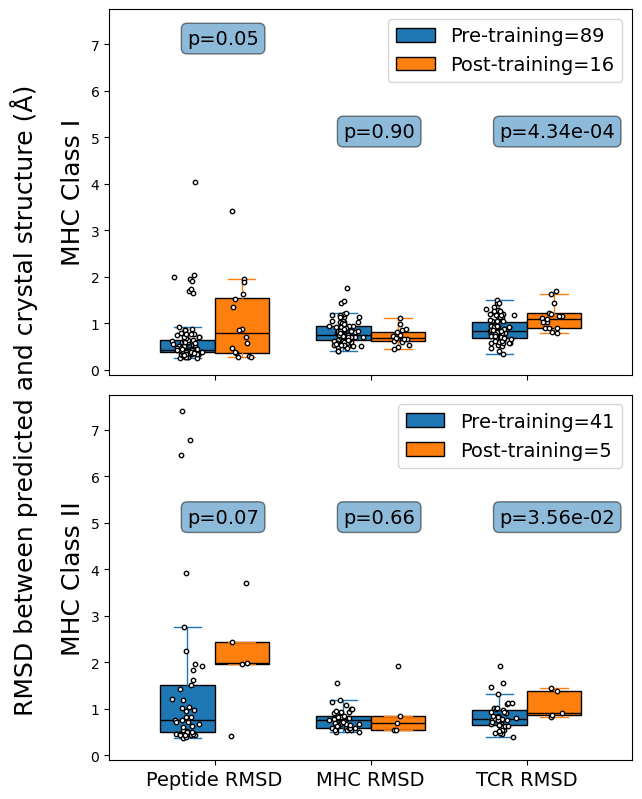

In [17]:
_ = plot_rmsd_bars_by_mhc_class(
    pdb_af3,
    "af3",
    # title="RMSD Breakdown by ",
)

In [7]:
for mhc_class in ["I", "II"]:
    print("MHC Class", mhc_class)

    print(
        "TCR RMSD:",
        pdb_af3.filter(pl.col("mhc_class") == mhc_class)
        .select("tcr_rmsd_af3_4")
        .median()
        .item(),
    )
    print(
        "MHC RMSD:",
        pdb_af3.filter(pl.col("mhc_class") == mhc_class)
        .select("mhc_rmsd_af3_4")
        .median()
        .item(),
    )
    print(
        "Peptide RMSD:",
        pdb_af3.filter(pl.col("mhc_class") == mhc_class)
        .select("peptide_rmsd_af3_4")
        .median()
        .item(),
    )

MHC Class I
TCR RMSD: 0.8770019963144597
MHC RMSD: 0.730442575855089
Peptide RMSD: 0.43887069468344464
MHC Class II
TCR RMSD: 0.8083764677610223
MHC RMSD: 0.7372132980671237
Peptide RMSD: 0.8226416406931327


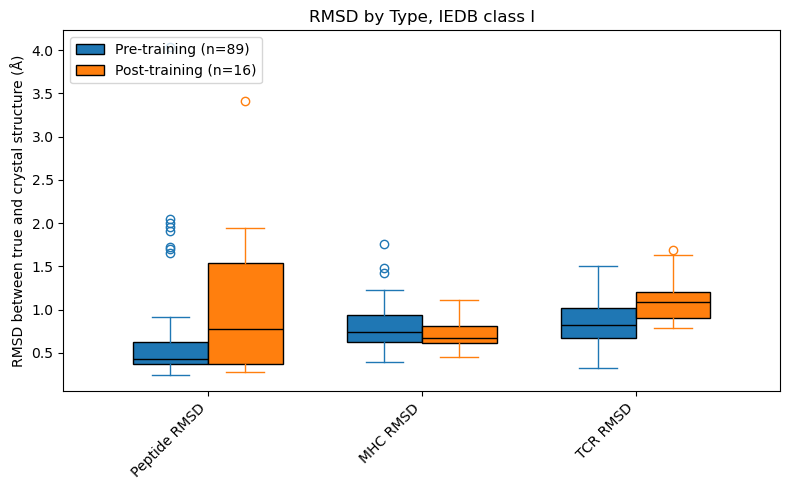

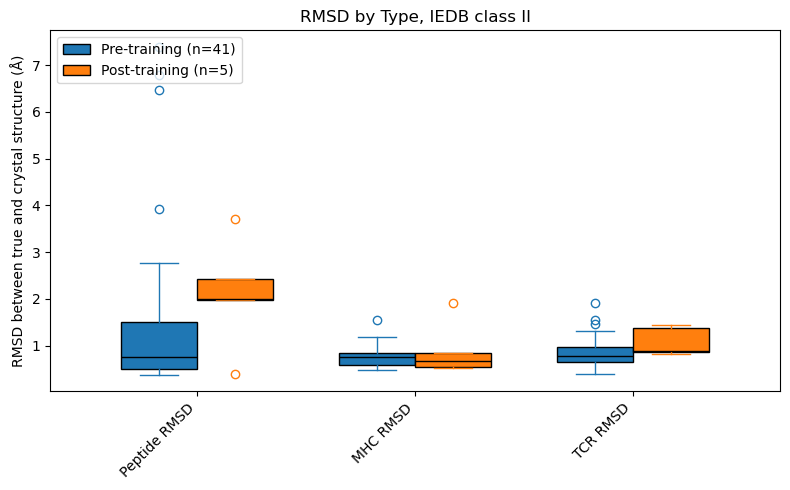

In [8]:
fig = plot_rmsd_bars_all(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    "af3",
    title="RMSD by Type, IEDB class I",
)
fig = plot_rmsd_bars_all(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    "af3",
    title="RMSD by Type, IEDB class II",
)

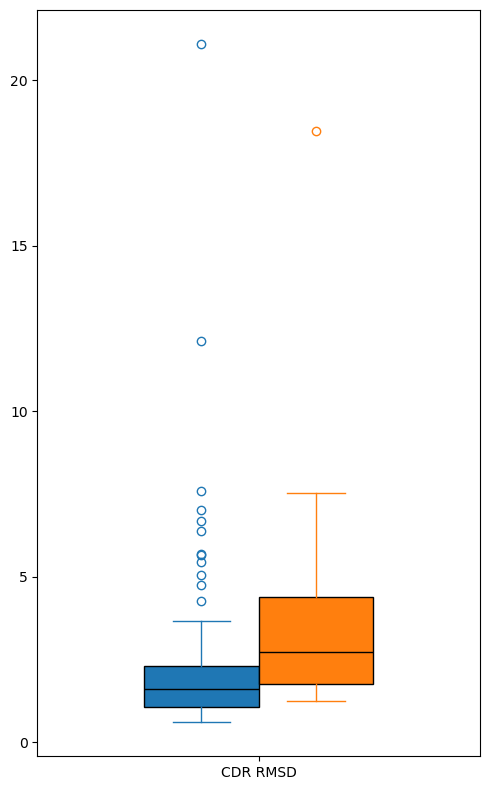

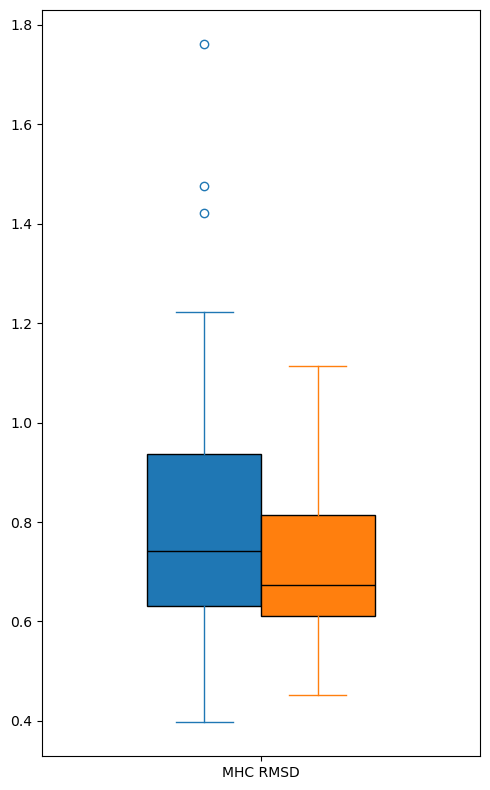

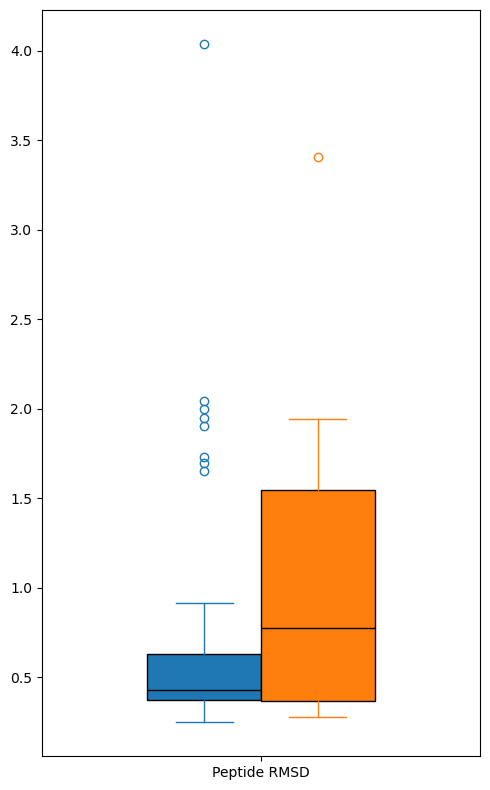

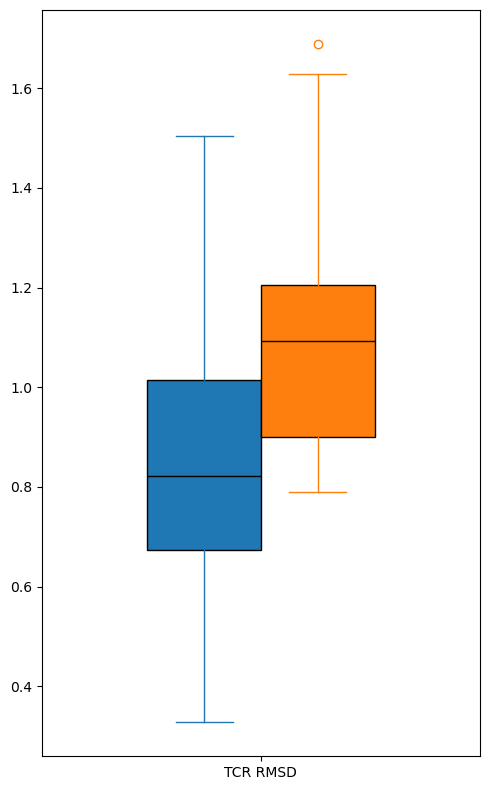

In [9]:
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3", "cdr")
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3", "mhc")
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3", "peptide")
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3", "tcr")